In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
from livelossplot import PlotLosses
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST

import decent_bench.utils.interoperability as iop
from decent_bench import benchmark
from decent_bench.agents import Agent
from decent_bench.algorithms import decentralized
from decent_bench.algorithms.utils import pytorch_initialization
from decent_bench.costs import PyTorchCost
from decent_bench.datasets import PyTorchDatasetHandler
from decent_bench.metrics import metric_library as ml
from decent_bench.networks import P2PNetwork
from decent_bench.utils.pytorch_utils import ArgmaxActivation, SimpleLinearModel
from decent_bench.utils.types import SupportedDevices, SupportedFrameworks


In [2]:
iterations = 1000
n_trials = 1
n_agents = 5
state_snapshot_period = 50
samples_per_partition = 1000
batch_size = 64
device = SupportedDevices.CPU
use_dataloader = False
compile_model = False

table_metrics = [
    ml.ConsensusError([min, np.average, max]),
    ml.GradientCalls([np.average, sum]),
    ml.SentMessages([np.average, sum]),
    ml.Accuracy([min, np.average, max], fmt=".2%"),
    ml.Precision([min, np.average, max], fmt=".2%"),
    ml.Recall([min, np.average, max], fmt=".2%"),
    ml.Loss([min, np.average, max]),
]

plot_metrics = [
    ml.ConsensusError([], x_log=False, y_log=True),
    ml.Accuracy([], x_log=False, y_log=False),
    ml.Precision([], x_log=False, y_log=False),
    ml.Recall([], x_log=False, y_log=False),
    ml.Loss([], x_log=False, y_log=False),
]

In [3]:
torch_device = iop.device_to_framework_device(device, SupportedFrameworks.PYTORCH)
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
mnist_train = MNIST(root="data", train=True, download=True, transform=transform, target_transform=torch.tensor)
mnist_test = MNIST(root="data", train=False, download=True, transform=transform, target_transform=torch.tensor)

train_dataset = PyTorchDatasetHandler(
    torch_dataset=mnist_train,
    n_features=28 * 28,
    n_targets=10,
    n_partitions=n_agents,
    samples_per_partition=samples_per_partition,
    heterogeneity=False,
)
# train_dataset = PyTorchDatasetHandler(
#     torch_dataset=mnist_train,
#     n_features=28 * 28,
#     n_targets=10,
#     n_partitions=n_agents,
#     samples_per_partition=samples_per_partition,
#     heterogeneity=True,
#     targets_per_partition=2,
# )
test_dataset = PyTorchDatasetHandler(
    torch_dataset=mnist_test,
    n_features=28 * 28,
    n_targets=10,
    n_partitions=n_agents,
    samples_per_partition=samples_per_partition,
    heterogeneity=False,
)
# test_dataset = PyTorchDatasetHandler(
#     torch_dataset=mnist_test,
#     n_features=28 * 28,
#     n_targets=10,
#     n_partitions=n_agents,
#     samples_per_partition=samples_per_partition,
#     heterogeneity=True,
#     targets_per_partition=2,
# )


def model_generator() -> torch.nn.Module:
    """Generate a simple linear model for the MNIST dataset."""
    return SimpleLinearModel(
        input_size=train_dataset.n_features,
        hidden_sizes=[32, 16],
        output_size=train_dataset.n_targets,
    )

### Setup benchmark problem

In [4]:
costs = [
    PyTorchCost(
        dataset=p,
        model=model_generator(),
        loss_fn=nn.CrossEntropyLoss(),
        final_activation=ArgmaxActivation(),
        batch_size=batch_size,
        device=device,
        use_dataloader=use_dataloader,
        dataloader_kwargs={"pin_memory": True},
        compile_model=compile_model,
        compile_kwargs={"mode": "reduce-overhead"},
    )
    for p in train_dataset.get_partitions()
]
agents = [Agent(i, cost, state_snapshot_period=state_snapshot_period) for i, cost in enumerate(costs)]
graph = nx.complete_graph(n_agents)
network = P2PNetwork(graph=graph, agents=agents)
problem = benchmark.BenchmarkProblem(network=network, test_data=test_dataset.get_datapoints())
x0 = pytorch_initialization(network)
algorithms = [
    decentralized.DiNNO(iterations=iterations, x0=x0),
    decentralized.LT_ADMM(iterations=iterations, x0=x0),
]

### Run benchmark

In [5]:
result = benchmark.benchmark(algorithms=algorithms, benchmark_problem=problem, n_trials=n_trials, show_speed=True)

[03/31/26 01:47:32] INFO     No checkpoint manager provided, running benchmark without            ]8;id=248623;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py\_benchmark.py]8;;\:]8;id=195109;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py#266\266]8;;\
                             checkpointing. Progress cannot be resumed if interrupted.                             

                    INFO     Starting benchmark execution                                         ]8;id=560597;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py\_benchmark.py]8;;\:]8;id=85523;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py#351\351]8;;\

Output()

[03/31/26 01:48:15] INFO     Benchmark execution complete, thanks for using decent-bench          ]8;id=559096;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py\_benchmark.py]8;;\:]8;id=201823;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py#369\369]8;;\

### Compute metrics

In [6]:
metric_result = benchmark.compute_metrics(
    benchmark_result=result,
    table_metrics=table_metrics,
    plot_metrics=plot_metrics,
)

Output()

Output()

### Display metrics

[03/31/26 01:53:15] INFO     Empirical-risk cost functions are in use. Compute counters increment by  ]8;id=661499;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=329372;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#67\67]8;;\
                             the number of samples processed in each method call, which can lead to                
                             large raw counts. Applying scaling factor of 'scale_compute=1.0' to ['nr              
                             gradient calls'] metrics for display.                                                 

                    INFO                                                                              ]8;id=811518;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=498030;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#98\98]8;;\
                             +-------------------------+---------------------+---------------------+               
                             | Metric (statistic)      | DiNNO               | LT-ADMM             |               
                             +=========================+=====================+=====================+               
                             | consensus error (min)   | 1.97e-02 ± 0.00e+00 | 1.77e-02 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | consensus error (avg)   | 2.13e-02 ± 0.00e+00 | 2.05e-02 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | consensus error (max)   | 2.28e-02 ± 0.00e+00 | 2.27e-02 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | nr gradient calls (avg) | 3.20e+05 ± 0.00e+00 | 3.20e+05 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | nr gradient calls (sum) | 1.60e+06 ± 0.00e+00 | 1.60e+06 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | nr sent messages (avg)  | 4.00e+03 ± 0.00e+00 | 4.00e+03 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | nr sent messages (sum)  | 2.00e+04 ± 0.00e+00 | 2.00e+04 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | accuracy (min)          | 87.08% ± 0.00%      | 86.28% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | accuracy (avg)          | 87.23% ± 0.00%      | 86.46% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | accuracy (max)          | 87.44% ± 0.00%      | 86.56% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | precision (min)         | 87.08% ± 0.00%      | 86.28% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | precision (avg)         | 87.23% ± 0.00%      | 86.46% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | precision (max)         | 87.44% ± 0.00%      | 86.56% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | recall (min)            | 87.08% ± 0.00%      | 86.28% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | recall (avg)            | 87.23% ± 0.00%      | 86.46% ± 0.00%    

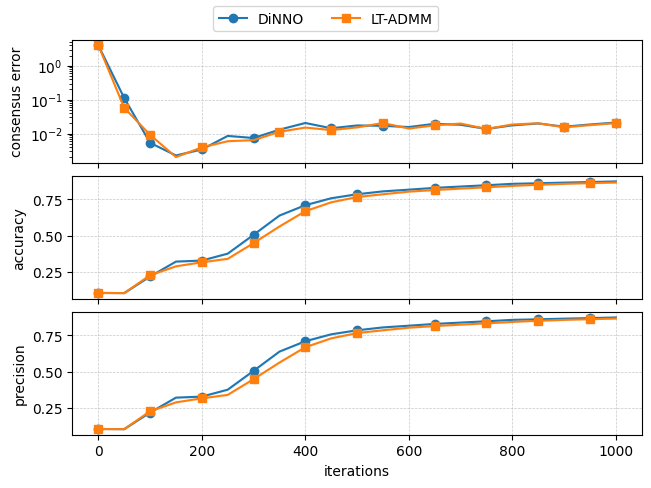

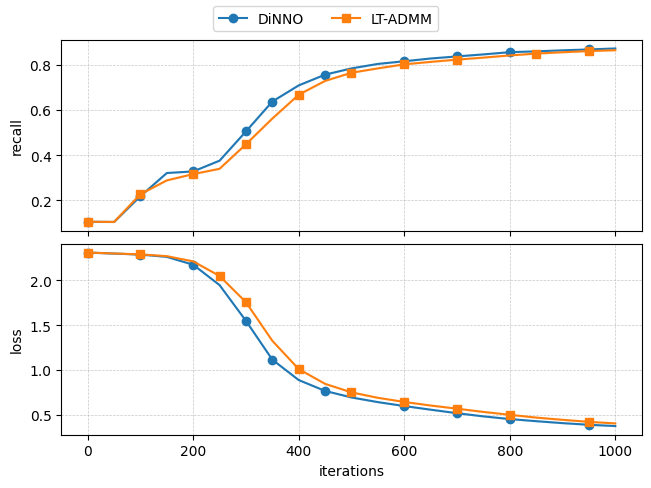

In [7]:
benchmark.display_metrics(metrics_result=metric_result)

### Visualize agents

'Results for DiNNO, 1 trials'

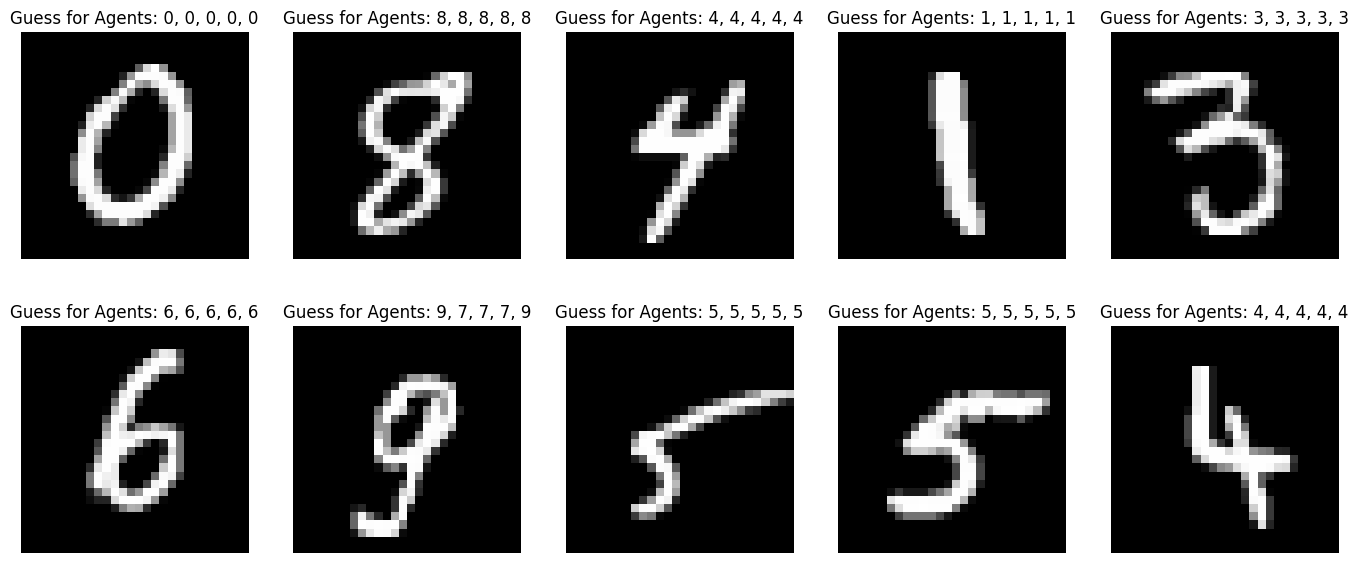

'Results for LT-ADMM, 1 trials'

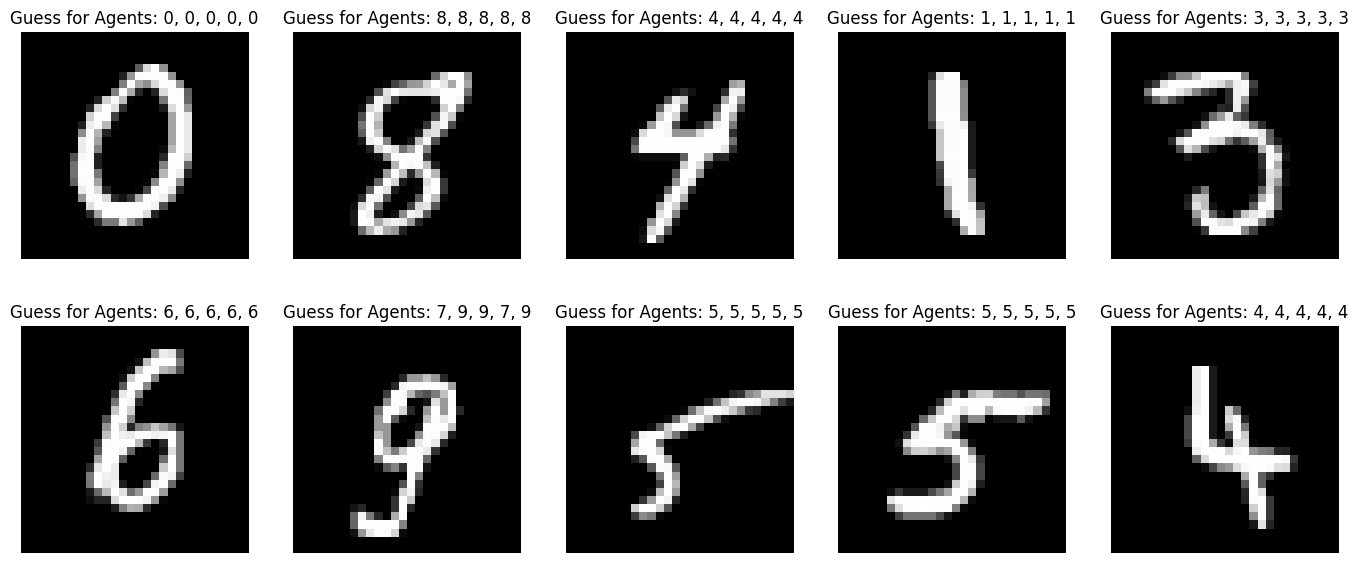

In [17]:
test_loader = DataLoader(test_dataset.get_datapoints(), batch_size=10, shuffle=True)
data_iter = iter(test_loader)
images, labels = next(data_iter)
images, labels = images.to(torch_device), labels.to(torch_device)
for alg, networks in result.states.items():
    display(f"Results for {alg.name}, {len(networks)} trials")
    for n in networks:
        all_agents = n.agents()
        all_preds = [[] for _ in range(len(labels))]
        for agent in all_agents:
            if not isinstance(agent.cost, PyTorchCost):
                raise ValueError("Cost is not a PyTorchCost, cannot compute predictions.")
            preds = agent.cost.predict(agent.x, images)
            for i in range(len(labels)):
                all_preds[i].append(preds[i])

        fig, ax = plt.subplots(2, len(labels) // 2, figsize=(17, 7))
        for i in range(len(labels)):
            row = i // (len(labels) // 2)
            col = i % (len(labels) // 2)
            ax[row, col].imshow(images[i].reshape(28, 28).cpu(), cmap="gray")
            ax[row, col].set_title(f"Guess for Agents: {', '.join(map(str, all_preds[i]))}")
            ax[row, col].axis("off")
        plt.show()

### Centralized solution

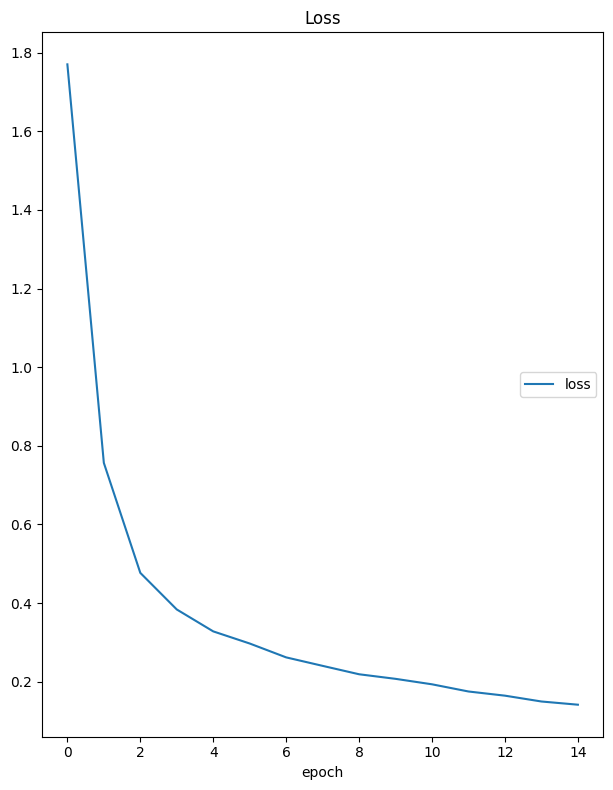

Loss
	loss             	 (min:    0.141, max:    1.770, cur:    0.141)


In [18]:
model = model_generator()
model.to(torch_device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 15
criterion = nn.CrossEntropyLoss()
liveloss = PlotLosses()
model.train()
dataloader = DataLoader(train_dataset.get_datapoints(), batch_size=batch_size, shuffle=True, pin_memory=True)
for epoch in range(epochs):
    running_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(torch_device), targets.to(torch_device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.detach()
    epoch_loss = running_loss / len(dataloader)
    liveloss.update({"loss": epoch_loss.item()})
    liveloss.send()

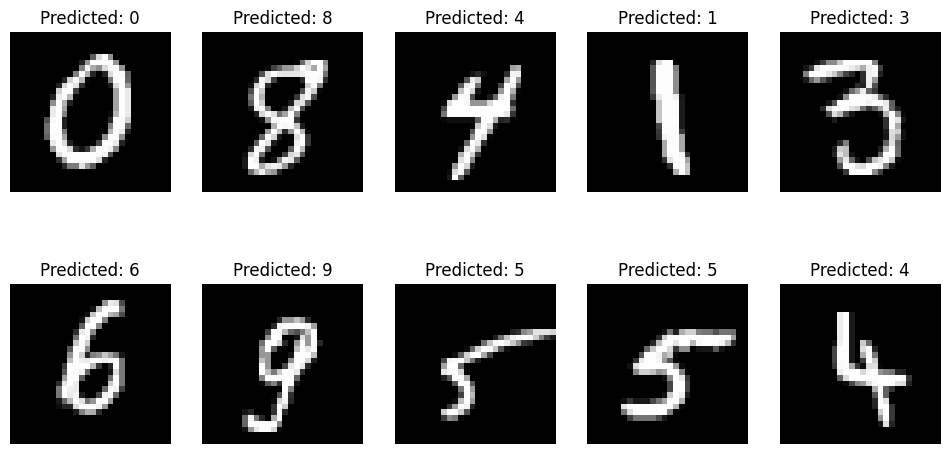

In [19]:
# Visualize a few mnist test samples with predictions
model.eval()
outputs = model(images)
predicted = torch.argmax(outputs, 1)
# Plot images with predicted labels
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(images[i].cpu().view(28, 28), cmap="gray")
    ax.set_title(f"Predicted: {predicted[i].item()}")
    ax.axis("off")
plt.show()